In [1]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


No null values found.

--- Overall Churn Rate ---
   churn_rate_pct  total_customers  churned_customers
0           20.37            10000               2037

--- Churn by Geography ---
  Geography  total_customers  churned  churn_rate_pct
0   Germany             2509      814           32.44
1     Spain             2477      413           16.67
2    France             5014      810           16.15

--- Churn by Age Group ---
  age_group  total_customers  churned  churn_rate_pct
0     50-59              869      487           56.04
1     40-49             2618      806           30.79
2       60+              526      147           27.95
3     30-39             4346      473           10.88
4  Under 30             1641      124            7.56

--- Churn by Activity Status ---
   IsActiveMember  total_customers  churned  churn_rate_pct
0               0             4849     1302           26.85
1               1             5151      735           14.27

--- Avg Balance/Salary/Tenure b

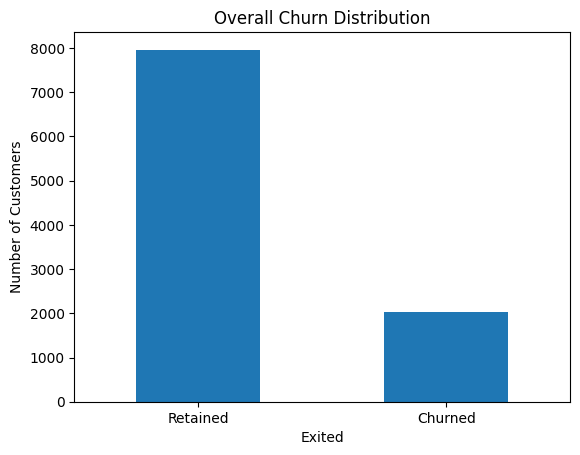

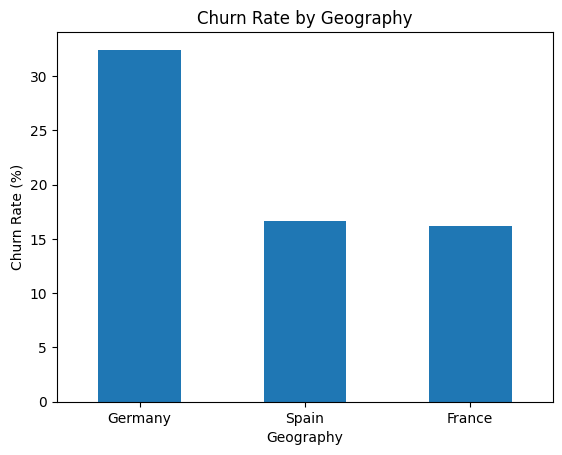

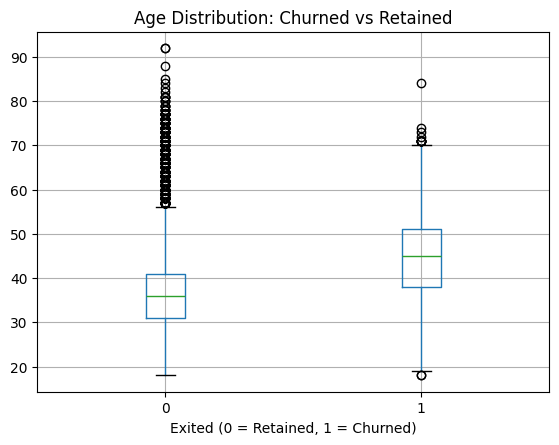

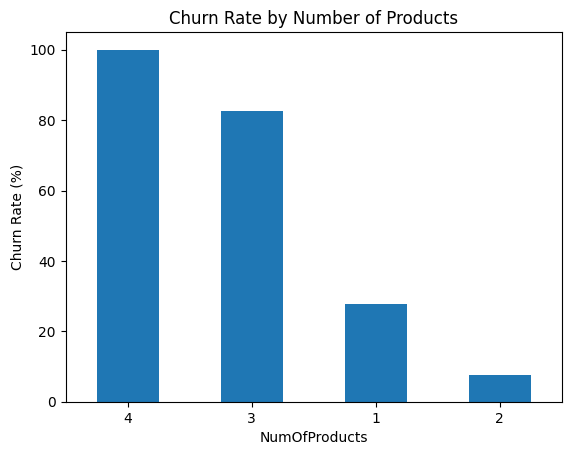

In [6]:
"""
Customer Churn Prediction — Week 1: Dataset + SQL + Cleaning
Dataset: Bank Customer Churn (Kaggle), 10,000 rows, target column 'Exited'.
"""

import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = "Churn_Modelling.csv"  # rename to match your downloaded file


# ---------------------------------------------------------------------------
# Load & inspect
# ---------------------------------------------------------------------------
def load_data(path: str = DATA_PATH) -> pd.DataFrame:
    try:
        df = pd.read_csv(path)
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"Dataset not found at '{path}'. Download it from Kaggle and "
            "upload it to your working directory first."
        ) from e
    return df


# ---------------------------------------------------------------------------
# Clean
# ---------------------------------------------------------------------------
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Drop duplicates, drop ID columns that don't help prediction, check nulls."""
    before = len(df)
    df = df.drop_duplicates()

    # Columns that identify a customer but carry no predictive signal
    id_cols = [c for c in ["RowNumber", "CustomerId", "Surname"] if c in df.columns]
    df = df.drop(columns=id_cols)

    dropped = before - len(df)
    if dropped:
        print(f"Dropped {dropped} duplicate row(s).")

    null_counts = df.isnull().sum()
    if null_counts.any():
        print("Null values found:\n", null_counts[null_counts > 0])
    else:
        print("No null values found.")

    return df


# ---------------------------------------------------------------------------
# SQL analysis
# ---------------------------------------------------------------------------
def build_sql_connection(df: pd.DataFrame) -> sqlite3.Connection:
    conn = sqlite3.connect(":memory:")
    df.to_sql("customers", conn, index=False, if_exists="replace")
    return conn


def run_query(conn: sqlite3.Connection, query: str) -> pd.DataFrame:
    try:
        return pd.read_sql_query(query, conn)
    except (sqlite3.OperationalError, pd.errors.DatabaseError) as e:
        raise RuntimeError(f"SQL query failed: {e}\nQuery:\n{query}") from e


OVERALL_CHURN_RATE_QUERY = """
    SELECT
        ROUND(100.0 * SUM(Exited) / COUNT(*), 2) AS churn_rate_pct,
        COUNT(*) AS total_customers,
        SUM(Exited) AS churned_customers
    FROM customers
"""

CHURN_BY_GEOGRAPHY_QUERY = """
    SELECT
        Geography,
        COUNT(*) AS total_customers,
        SUM(Exited) AS churned,
        ROUND(100.0 * SUM(Exited) / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY Geography
    ORDER BY churn_rate_pct DESC
"""

CHURN_BY_AGE_GROUP_QUERY = """
    SELECT
        CASE
            WHEN Age < 30 THEN 'Under 30'
            WHEN Age < 40 THEN '30-39'
            WHEN Age < 50 THEN '40-49'
            WHEN Age < 60 THEN '50-59'
            ELSE '60+'
        END AS age_group,
        COUNT(*) AS total_customers,
        SUM(Exited) AS churned,
        ROUND(100.0 * SUM(Exited) / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY age_group
    ORDER BY churn_rate_pct DESC
"""

CHURN_BY_ACTIVITY_QUERY = """
    SELECT
        IsActiveMember,
        COUNT(*) AS total_customers,
        SUM(Exited) AS churned,
        ROUND(100.0 * SUM(Exited) / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY IsActiveMember
"""

AVG_BALANCE_BY_CHURN_QUERY = """
    SELECT
        Exited,
        ROUND(AVG(Balance), 2) AS avg_balance,
        ROUND(AVG(EstimatedSalary), 2) AS avg_salary,
        ROUND(AVG(Tenure), 2) AS avg_tenure
    FROM customers
    GROUP BY Exited
"""


# ---------------------------------------------------------------------------
# Visualizations
# ---------------------------------------------------------------------------
def plot_churn_distribution(df: pd.DataFrame) -> None:
    df["Exited"].value_counts().rename({0: "Retained", 1: "Churned"}).plot(
        kind="bar", title="Overall Churn Distribution"
    )
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=0)
    plt.show()


def plot_churn_by_geography(df: pd.DataFrame) -> None:
    (
        df.groupby("Geography")["Exited"].mean().sort_values(ascending=False) * 100
    ).plot(kind="bar", title="Churn Rate by Geography")
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=0)
    plt.show()


def plot_churn_by_age(df: pd.DataFrame) -> None:
    df.boxplot(column="Age", by="Exited")
    plt.title("Age Distribution: Churned vs Retained")
    plt.suptitle("")
    plt.xlabel("Exited (0 = Retained, 1 = Churned)")
    plt.show()


def plot_churn_by_products(df: pd.DataFrame) -> None:
    (
        df.groupby("NumOfProducts")["Exited"].mean().sort_values(ascending=False) * 100
    ).plot(kind="bar", title="Churn Rate by Number of Products")
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=0)
    plt.show()


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    df = load_data()
    df = clean_data(df)
    df.to_csv("churn_clean.csv", index=False)

    conn = build_sql_connection(df)
    print("\n--- Overall Churn Rate ---")
    print(run_query(conn, OVERALL_CHURN_RATE_QUERY))
    print("\n--- Churn by Geography ---")
    print(run_query(conn, CHURN_BY_GEOGRAPHY_QUERY))
    print("\n--- Churn by Age Group ---")
    print(run_query(conn, CHURN_BY_AGE_GROUP_QUERY))
    print("\n--- Churn by Activity Status ---")
    print(run_query(conn, CHURN_BY_ACTIVITY_QUERY))
    print("\n--- Avg Balance/Salary/Tenure by Churn Status ---")
    print(run_query(conn, AVG_BALANCE_BY_CHURN_QUERY))

    plot_churn_distribution(df)
    plot_churn_by_geography(df)
    plot_churn_by_age(df)
    plot_churn_by_products(df)


if __name__ == "__main__":
    main()

Key Insights:

1. Geography: Germany has by far the highest churn rate (~32%) compared to
Spain (16.67%) and France (16.15%) - customers in Germany are roughly twice
as likely to leave as customers in either other country.

2. Age Group: Churn rises sharply with age - customers 50-59 churn at 56.04%,
more than double the 40-49 group (30.79%) and over 7x the Under-30 group
(7.56%). This is the strongest pattern in the data.

3. Activity Status: Inactive members churn nearly 2x as often as active ones
(26.85% vs. 14.27%), confirming engagement is a meaningful retention signal.

4. Balance: Churned customers had a higher average balance ($91,108.54) than
retained customers ($72,745.30) - the bank isn't just losing low-value
customers, it's losing wealthier ones.

5. Tenure: Tenure barely differs between churned (4.93 yrs) and retained
(5.03 yrs) customers - unlike age or activity, how long someone's been a
customer isn't a strong churn predictor on its own.